## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## Importing necessary libraries

In [37]:
# Installing the libraries with the specified version.
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.8 seaborn==0.13.1 scikit-learn==1.5 sklearn-pandas==2.2.0 -q --user

**Note**:

1. After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab), write the relevant code for the project from the next cell, and run all cells sequentially from the next cell.

2. On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [38]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# To build model for prediction
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

#for preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
)

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [39]:
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
Loan = pd.read_csv("/content/drive/MyDrive/utaiml/Project 2 - Loan Campaign/Loan_Modelling.csv")
data = Loan.copy()

## Data Overview

* Observations
* Sanity checks

In [41]:
data.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
ID,5000.0,2500.500000,1443.520003,1.0,1250.75,2500.5,3750.25,5000.0
Age,5000.0,45.338400,11.463166,23.0,35.00,45.0,55.00,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.00,20.0,30.00,43.0
Income,5000.0,73.774200,46.033729,8.0,39.00,64.0,98.00,224.0
ZIPCode,5000.0,93169.257000,1759.455086,90005.0,91911.00,93437.0,94608.00,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.00,2.0,3.00,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.70,1.5,2.50,10.0
Education,5000.0,1.881000,0.839869,1.0,1.00,2.0,3.00,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.00,0.0,101.00,635.0
Personal_Loan,5000.0,0.096000,0.294621,0.0,0.00,0.0,0.00,1.0


In [42]:
print("first 5 Rows:")
data.head()

first 5 Rows:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [43]:
print("last 5 Rows:")
data.tail()

last 5 Rows:


,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


In [44]:
# Number of rows and columns in the data using the shape attribute of the DataFrame.
rows, columns = data.shape


print(f'Number of Rows: {rows}')
print(f'Number of Columns: {columns}')

Number of Rows: 5000
Number of Columns: 14


In [45]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [46]:
# Determine if there is any missing data.
missing_values = data.isnull().sum()

# Check for nulls and NaN values in the dataset.
print('Null values ' + str(data.isnull().sum()) + '\n')
print('NaN values ' + str(data.isna().sum()) + '\n')

# Output if there are any missing data points in the dataset.
if missing_values.sum() > 0:
    print('There are missing data points in the Personal Loan dataset.')
else:
    print('There are no missing data points in the Personal Load dataset.')

Null values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

NaN values ID                    0
Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
dtype: int64

There are no missing data points in the Personal Load dataset.


In [47]:
# Drop the ID column from the dataset.
if 'ID' in data.columns:
    data.drop(['ID'], axis=1, inplace=True)

# Retrieve the first 5 rows of the dataset after dropping the ID column.
print('First 5 rows of the dataset after dropping the ID column:')
data.head()

First 5 rows of the dataset after dropping the ID column:


,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [48]:
# Define bins and labels
bins = [0, 20, 50, 100, 500, float('inf')]
labels = ['0–20K', '20K–50K', '50K-100k','100k-500k', '500k+']

# Create a new column with the mortgage range
data['Mortgage_Range'] = pd.cut(data['Mortgage'], bins=bins, labels=labels, right=False)

# Count how many fall into each range
mortgage_range_distribution = data['Mortgage_Range'].value_counts().sort_index()

print('Distribution of Mortgages by Range:')
print(mortgage_range_distribution)

Distribution of Mortgages by Range:
Mortgage_Range
0–20K        3462
20K–50K         0
50K-100k      270
100k-500k    1242
500k+          26
Name: count, dtype: int64


In [49]:


# Map Education codes to labels
education_map = {
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Advanced/Professional'
}

data['Education_Label'] = data['Education'].map(education_map)

# Create the cross-tab
zip_education_crosstab = pd.crosstab(data['ZIPCode'], data['Education_Label'])
# Keep only ZIP codes with total count > 20
zipcode_education_filtered = zip_education_crosstab[zip_education_crosstab.sum(axis=1) > 20]

# Sort by ZIP code (optional)
zipcode_education_filtered = zipcode_education_filtered.sort_index()

# Display
print('Cross-tabulation of ZIP code and Education (Total count > 20):')
print(zipcode_education_filtered.to_string())

Cross-tabulation of ZIP code and Education (Total count > 20):
Education_Label  Advanced/Professional  Graduate  Undergrad
ZIPCode                                                    
90024                               18        12         20
90089                               10        14         22
90095                               26        20         25
90245                               21        12         17
91107                               12         5          8
91320                               17        14         22
91330                               12        15         19
91380                               14         4          4
91711                               19        18         15
91768                                7         9          5
92028                               10        11         11
92037                               17        12         25
92093                               15        17         19
92121                                

In [50]:

# Checking to see if there is a correlation between Education level and Mortgage amount.
# Calculate the correlation between 'Mortgage' and 'Education'
correlation = data['Mortgage'].corr(data['Education'])

print(f"The correlation between Mortgage and Education is: {correlation}")

The correlation between Mortgage and Education is: -0.033327124629950425


In [67]:

# Checking to see if there is a correlation between Education level and Mortgage amount.
# Calculate the correlation between 'Mortgage' and 'Education'
correlation = data['Mortgage'].corr(data['Income'])

print(f"The correlation between Mortgage and Income is: {correlation}")

The correlation between Mortgage and Income is: 0.2068062278031723


**Data Quality Observation**
1. The dataset contains 5,000 entries with 14 columns capturing demographic, financial, and behavioral attributes of customers.

2. No missing values are present in any column, indicating complete data coverage across all records.

3. Data types are appropriate and consistent:

  Mostly integer types for categorical and count data (e.g., Age, Income, Education).

  One float column for average credit card spending (CCAvg).

The absence of nulls reduces potential bias and errors associated with handling missing data, ensuring reliable insights and model performance.






**Observation on ZIP Code and Education Analysis**

The cross-tabulation of ZIP codes against education levels reveals varying distributions of educational attainment across different geographic areas.

Some ZIP codes (e.g., 94720, 95616, and 94305) show higher counts across all education levels, indicating these areas have a larger population or more customers represented in the dataset.

Other ZIP codes have smaller counts, suggesting fewer customers or less representation.

This spatial variation in education could inform targeted marketing or financial product strategies, tailoring offers based on regional education profiles.

**Observation on Mortgage Distribution**

The majority of customers have mortgages in the 0–20K range, likely indicating many customers have no or low mortgage balances.

There is a noticeable absence of mortgages in the 20K–50K range, which might be due to binning strategy or data characteristics that could warrant further review.

Substantial numbers of customers hold mortgages in the 50K–100K and 100K–500K ranges, reflecting a diverse mortgage portfolio.

A small portion of customers have mortgages exceeding 500K, representing high-value mortgage holders.

Understanding these mortgage ranges helps identify segments with differing credit exposure and could guide risk assessment and product design.

## Exploratory Data Analysis.

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions**:

1. What is the distribution of mortgage attribute? Are there any noticeable patterns or outliers in the distribution?
2. How many customers have credit cards?
3. What are the attributes that have a strong correlation with the target attribute (personal loan)?
4. How does a customer's interest in purchasing a loan vary with their age?
5. How does a customer's interest in purchasing a loan vary with their education?

Question 1:
What is the distribution of the mortgage attribute? Are there any noticeable patterns or outliers in the distribution?



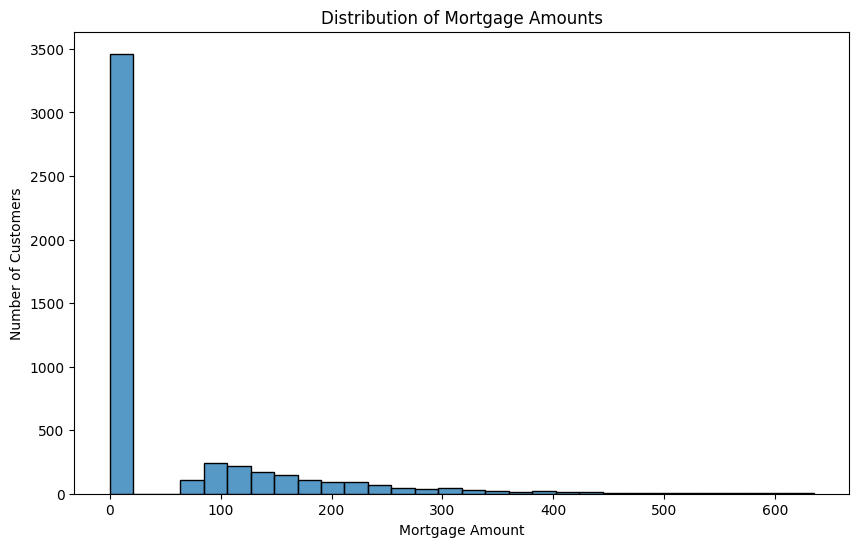

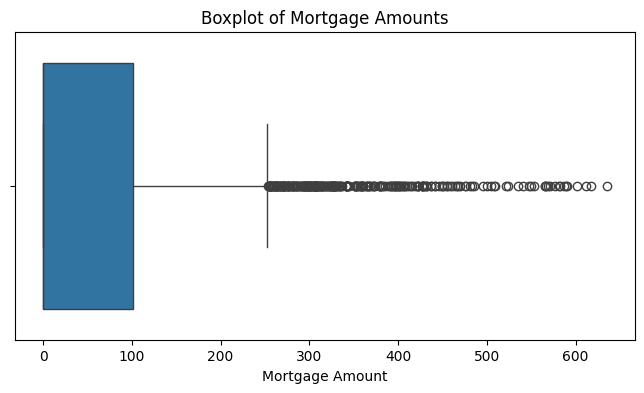

In [51]:
# Histogram to see distribution
plt.figure(figsize=(10,6))
sns.histplot(data['Mortgage'], bins=30, kde=False)
plt.title('Distribution of Mortgage Amounts')
plt.xlabel('Mortgage Amount')
plt.ylabel('Number of Customers')
plt.show()

# Boxplot to detect outliers
plt.figure(figsize=(8,4))
sns.boxplot(x=data['Mortgage'])
plt.title('Boxplot of Mortgage Amounts')
plt.xlabel('Mortgage Amount')
plt.show()

In [52]:

# Number of customers with no mortgage.
no_mortgage_count = data[data['Mortgage'] == 0].shape[0]

# Total number of customers.
total_customers = data.shape[0]

# Percentage of customers with no mortgage.
percentage_no_mortgage = (no_mortgage_count / total_customers) * 100

print(f"Number of customers with no mortgage: {no_mortgage_count:,}")
print(f"Total number of customers: {total_customers:,}")
print(f'Percentage of customers with no mortgage: {percentage_no_mortgage:.2f}%')

Number of customers with no mortgage: 3,462
Total number of customers: 5,000
Percentage of customers with no mortgage: 69.24%


**Observation: Distribution of Mortgage Amounts**

The mortgage amounts are highly right-skewed, with a large majority of customers having very low or zero mortgage balances.

Specifically, 3,462 customers out of 5,000 (69.24%) have no mortgage (Mortgage = 0), indicating that most customers do not currently hold a mortgage.

The histogram shows a sharp peak at zero, reinforcing this high proportion of zero mortgage values.

Beyond zero, mortgage amounts are distributed across a wide range, with fewer customers having mortgages from low to high values (up to around 600K).

The boxplot reveals a long tail of outliers representing customers with substantially larger mortgage amounts.

**Recommendation**

Since about 69% of customers currently have no mortgage, this represents a large untapped market for mortgage lending products.

Design targeted marketing campaigns aimed specifically at these no-mortgage customers to convert them into mortgage borrowers.

Question 2:
How many customers have credit cards?

Credit Card Ownership Counts:
CreditCard
0    3530
1    1470
Name: count, dtype: int64

Credit Card Ownership Percentage:
CreditCard
0    70.6
1    29.4
Name: count, dtype: float64


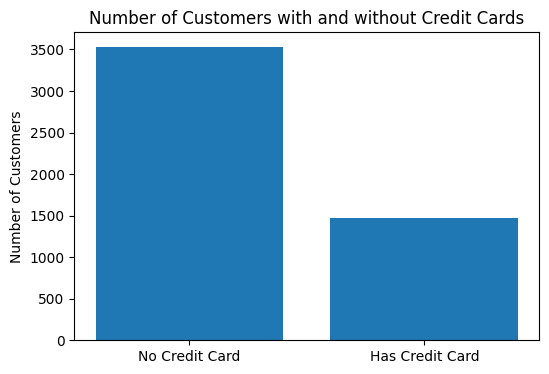

In [53]:
# Count of customers with and without credit cards
credit_card_counts = data['CreditCard'].value_counts()

# Print the counts
print("Credit Card Ownership Counts:")
print(credit_card_counts)

# Calculate percentage
credit_card_percent = credit_card_counts / len(data) * 100

print("\nCredit Card Ownership Percentage:")
print(credit_card_percent.round(2))

# Bar plot visualization
plt.figure(figsize=(6,4))
plt.bar(['No Credit Card', 'Has Credit Card'], credit_card_counts.sort_index())
plt.title('Number of Customers with and without Credit Cards')
plt.ylabel('Number of Customers')
plt.show()

**Observation: Credit Card Ownership**


Out of 5,000 customers, 1,470 (29.4%) have credit cards, while 3,530 (70.6%) do not.

The majority of customers currently do not hold a credit card, which might represent a segment with untapped potential for credit products or financial services.

This split suggests that credit card ownership is moderately common but not pervasive in this customer base.

Question 3:
What are the attributes that have a strong correlation with the target attribute (Personal_Loan)?

Correlation of attributes with Personal_Loan:
Income                0.502462
CCAvg                 0.366889
CD_Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
Securities_Account    0.021954
Age                  -0.007726
Experience           -0.007413
Online                0.006278
ZIPCode              -0.002974
CreditCard            0.002802
Name: Personal_Loan, dtype: float64


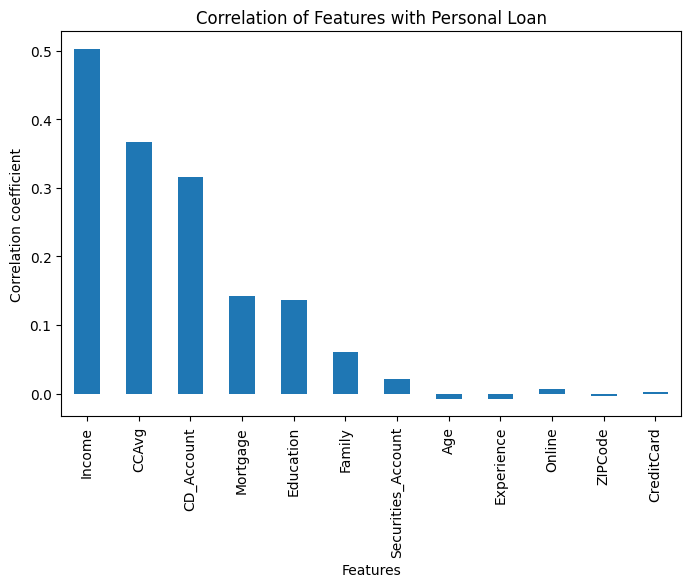

In [54]:
# Select only numeric columns
numeric_data = data.select_dtypes(include=['number'])

# Calculate correlation matrix
corr_matrix = numeric_data.corr()

# Extract correlations with Personal_Loan, sort by absolute value descending
target_corr = corr_matrix['Personal_Loan'].drop('Personal_Loan').sort_values(key=abs, ascending=False)

# Print correlation values
print("Correlation of attributes with Personal_Loan:")
print(target_corr)

# Bar plot to visualize correlations
plt.figure(figsize=(8,5))
target_corr.plot(kind='bar')
plt.title('Correlation of Features with Personal Loan')
plt.ylabel('Correlation coefficient')
plt.xlabel('Features')
plt.show()


Income shows the strongest positive correlation with personal loan purchase (0.50), indicating higher-income customers are more likely to buy personal loans.

Average credit card spending (CCAvg) and having a CD_Account also show moderate positive correlations (0.37 and 0.32, respectively), suggesting that customers with more active financial engagement tend to take personal loans.

Mortgage and Education have weaker but positive correlations (~0.14), indicating a slight tendency for customers with higher mortgages or education levels to purchase loans.

Attributes like Family, Securities_Account, and others show very weak or near-zero correlation, meaning they don’t have much linear relationship with loan uptake.

Interestingly, Age and Experience have very weak negative correlations, implying little to no direct linear influence on personal loan decisions.

Question 4:
How does a customer's interest in purchasing a loan vary with their age?

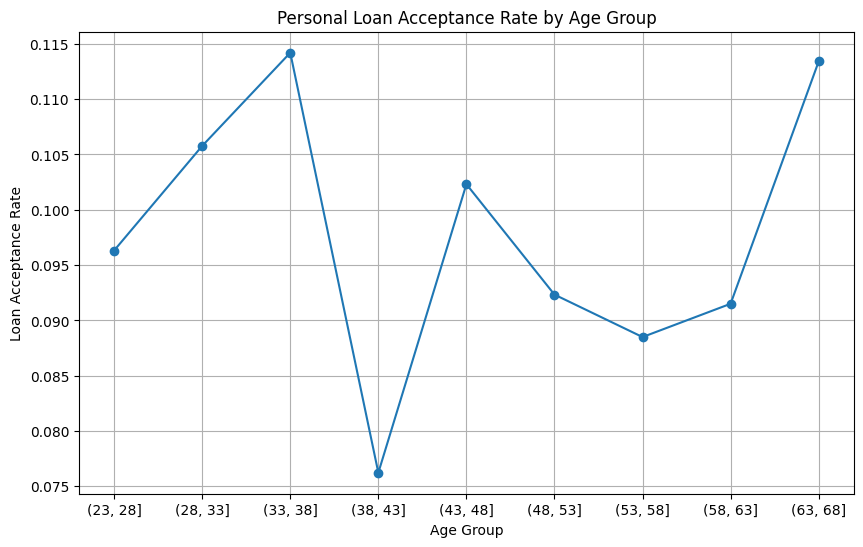

In [55]:
age_bins = range(data['Age'].min(), data['Age'].max() + 5, 5)
data['Age_Group'] = pd.cut(data['Age'], bins=age_bins)

# Calculate loan acceptance rate by age group
loan_by_age = data.groupby('Age_Group')['Personal_Loan'].mean()

# Plot the loan acceptance rate by age group
plt.figure(figsize=(10,6))
loan_by_age.plot(kind='line', marker='o')
plt.title('Personal Loan Acceptance Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Loan Acceptance Rate')
plt.grid(True)
plt.show()

**Observation: Personal Loan Acceptance Rate by Age Group**


Loan acceptance rates vary across age groups but generally remain between approximately 7.5% and 11.5%.

The highest acceptance rates are observed in the 33–38 and 63–68 age groups, suggesting younger middle-aged adults and older adults are more likely to take personal loans.

A noticeable dip occurs in the 38–43 age group, where acceptance rate drops to about 7.6%, the lowest among all groups.

The trend suggests that age influences loan interest in a non-linear manner, with both early middle age and senior age brackets showing relatively higher interest.

This insight can guide marketing efforts to target specific age ranges more effectively.

Question 5:
How does a customer's interest in purchasing a loan vary with their education?

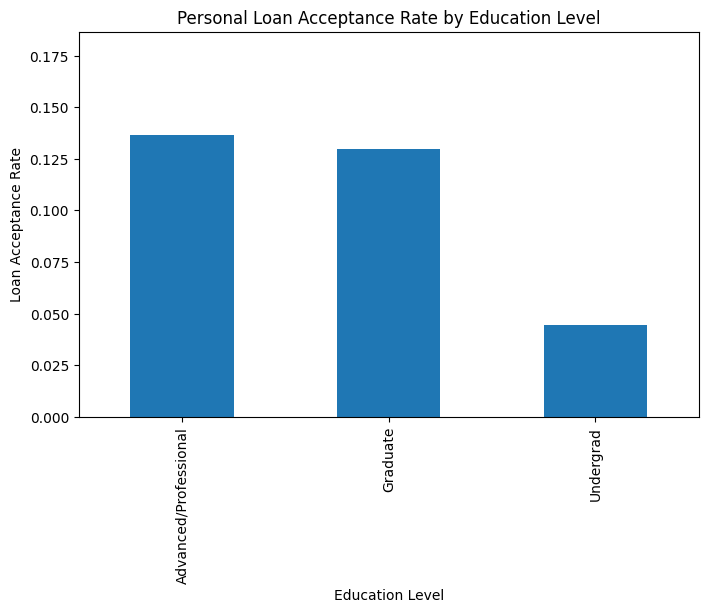

In [56]:
# Map education codes to labels (if not done already)
education_map = {
    1: 'Undergrad',
    2: 'Graduate',
    3: 'Advanced/Professional'
}
data['Education_Label'] = data['Education'].map(education_map)

# Calculate loan acceptance rate by education level
loan_by_education = data.groupby('Education_Label')['Personal_Loan'].mean().sort_index()

# Plot loan acceptance rate by education
plt.figure(figsize=(8,5))
loan_by_education.plot(kind='bar')
plt.title('Personal Loan Acceptance Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Loan Acceptance Rate')
plt.ylim(0, loan_by_education.max() + 0.05)
plt.show()

**Observation: Personal Loan Acceptance Rate by Education Level**


Customers with Advanced/Professional and Graduate education levels show significantly higher loan acceptance rates (approximately 13–14%) compared to those with an Undergraduate level (about 4.5%).

This suggests that customers with higher education levels are more likely to purchase personal loans.

The lower acceptance rate among undergraduates may reflect differences in income, financial knowledge, or creditworthiness.

This insight can help tailor marketing strategies by focusing more on graduates and advanced degree holders who are more receptive to personal loan offers.

Q6. Loan Acceptance Rate by Family Size

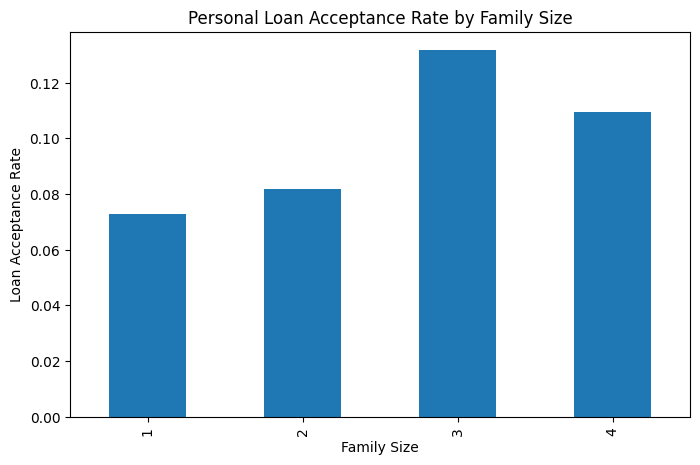

In [57]:
loan_by_family = data.groupby('Family')['Personal_Loan'].mean()

plt.figure(figsize=(8,5))
loan_by_family.plot(kind='bar')
plt.title('Personal Loan Acceptance Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Loan Acceptance Rate')
plt.show()

**Observation: Personal Loan Acceptance Rate by Family Size**


Loan acceptance rates vary noticeably by family size.

Customers with a family size of 3 have the highest acceptance rate at around 13%, followed by those with family size 4 at about 11%.

Smaller families (sizes 1 and 2) show lower acceptance rates, around 7–8%.

This suggests that customers with medium to larger family sizes may have a greater interest or need for personal loans, possibly due to increased financial responsibilities.

Targeting marketing campaigns toward families with 3 or more members could improve loan uptake.

# Summary of Key Observations


Mortgage: Majority (69%) have no mortgage; distribution is right-skewed with some high-value outliers.

Credit Cards: About 29% have credit cards, indicating moderate credit engagement.

Correlations: Income and credit card spending strongly correlate with loan uptake; education and mortgage show weaker positive links.

Age: Loan interest peaks in early 30s and late 60s, with a dip around late 30s to early 40s.

Education: Higher education levels correspond to higher loan acceptance rates.

Family Size: Loan uptake is highest among customers with family sizes of 3 or 4.

## Data Preprocessing

* Missing value treatment
* Feature engineering (if needed)
* Outlier detection and treatment (if needed)
* Preparing data for modeling
* Any other preprocessing steps (if needed)

In [70]:
# 1. Missing value treatment
# Check again and remove age group
if 'Age_Group' in data.columns:
    data.drop(['Age_Group'], axis=1, inplace=True)
print(data.isnull().sum())


# 2. Outlier treatment: Cap Mortgage at 95th percentile
cap = data['Mortgage'].quantile(0.95)
data['Mortgage_Capped'] = np.where(data['Mortgage'] > cap, cap, data['Mortgage'])

#3.Feature Enginereing
# Interaction feature: Income × Education
data['Income_Education'] = data['Income'] * data['Education']

# Interaction feature: Family size × Income
data['Family_Income'] = data['Family'] * data['Income']

# Interaction feature: CreditCard × CCAvg
data['CreditCard_CCAvg'] = data['CreditCard'] * data['CCAvg']

# 4. Preparing data for modeling

# Define features and target
X = data.drop(columns=['Personal_Loan'])
y = data['Personal_Loan']

# Select numeric and categorical columns
numeric_features = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage_Capped','Income_Education', 'Family_Income', 'CreditCard_CCAvg']
categorical_features = ['Education', 'Securities_Account', 'CD_Account', 'Online', 'CreditCard']

# Column transformer for scaling numeric and one-hot encoding categorical
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit preprocessor on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing complete. Data ready for modeling.")

Age                   0
Experience            0
Income                0
ZIPCode               0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal_Loan         0
Securities_Account    0
CD_Account            0
Online                0
CreditCard            0
Mortgage_Range        0
Education_Label       0
Mortgage_Capped       0
dtype: int64
Preprocessing complete. Data ready for modeling.


## Model Building

### Model Evaluation Criterion

1. Accuracy
  Definition: Proportion of correctly predicted instances (both positive and negative) over all predictions.

  Reason to use: Gives a quick overall measure of how well the model performs.

  Limitation: Can be misleading if the classes are imbalanced (e.g., if most customers don’t buy loans, a model predicting “no” always may have high accuracy but be useless).

2. Precision (Positive Predictive Value)
  Definition: Among the customers predicted to buy a loan, how many actually do buy it?

  Reason to use: Important when the cost of marketing to customers unlikely to buy is high (i.e., avoid wasting resources).

  Use case here: High precision means marketing efforts are more focused and efficient.

3. Recall (Sensitivity or True Positive Rate)
  Definition: Among all customers who actually bought loans, how many were correctly identified by the model?

  Reason to use: Important if the goal is to capture as many potential buyers as possible.

  Use case here: High recall ensures fewer potential loan customers are missed.

4. F1-Score
  Definition: Harmonic mean of precision and recall, balancing both.

  Reason to use: Useful when you want a balance between precision and recall.

  Use case here: When marketing budget is limited and both missing buyers and false targeting are costly.

5. ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
  Definition: Measures the ability of the model to discriminate between classes across all classification thresholds.

  Reason to use: Provides a threshold-independent measure of model performance.

  Use case here: Helps select the best model irrespective of a fixed probability cutoff; good for imbalanced data.

6. Confusion Matrix
  Definition: Table showing true positives, false positives, true negatives, and false negatives.

  Reason to use: Gives detailed insight into types of errors the model makes.

  Use case here: Helps understand trade-offs in predictions and tailor marketing strategies accordingly.

**Recommended Primary Metrics for This Project**


  Recall (or F1-Score) should be prioritized because:

  Bank want to capture as many real buyers as possible (high recall).

  ROC-AUC is useful for model comparison and threshold tuning.

  Accuracy is secondary, given possible class imbalance.



### Model Building

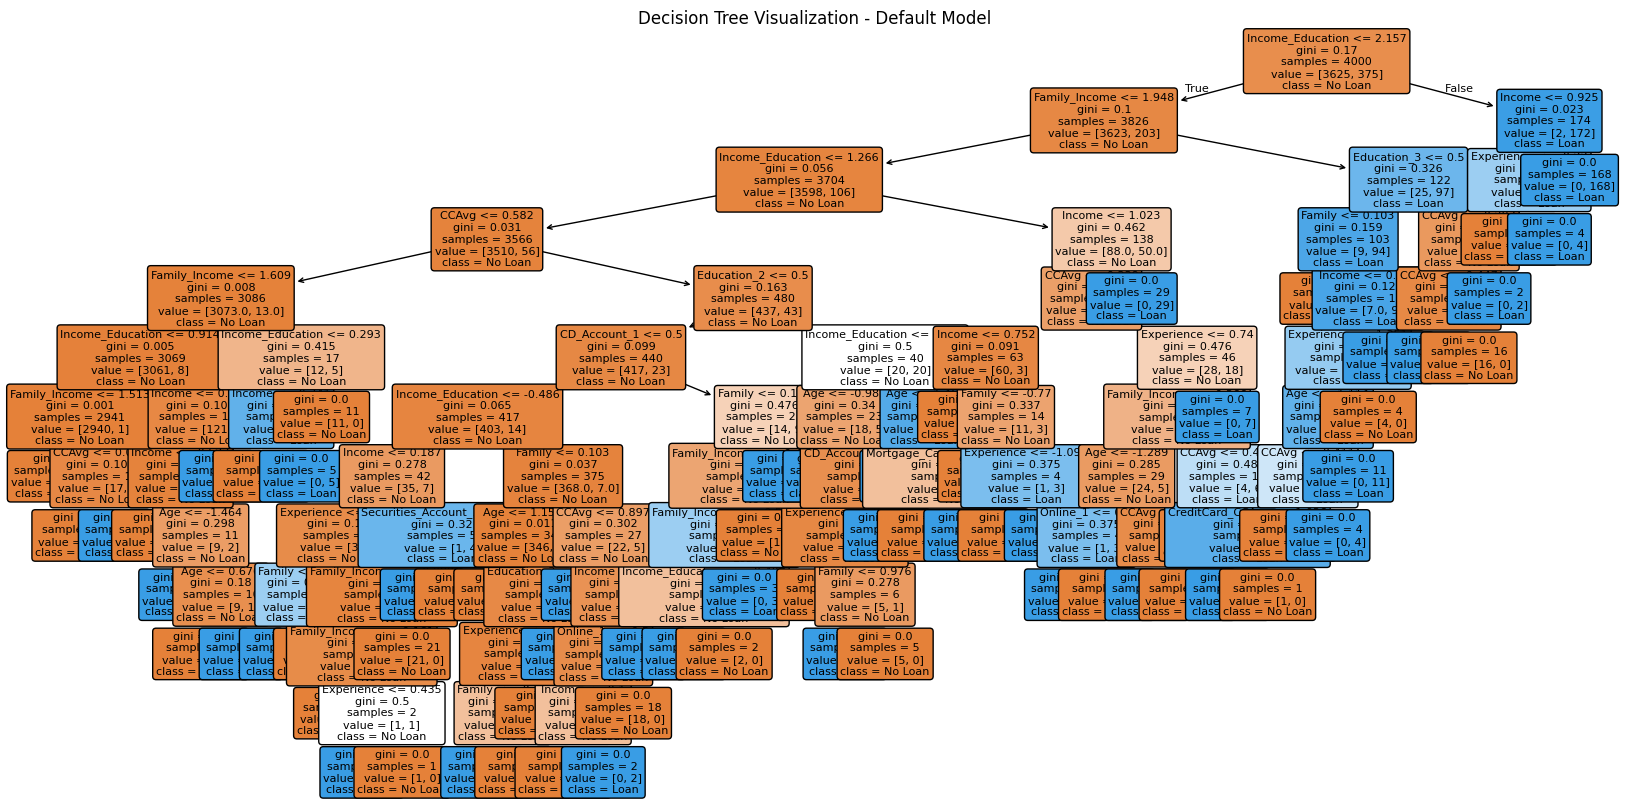

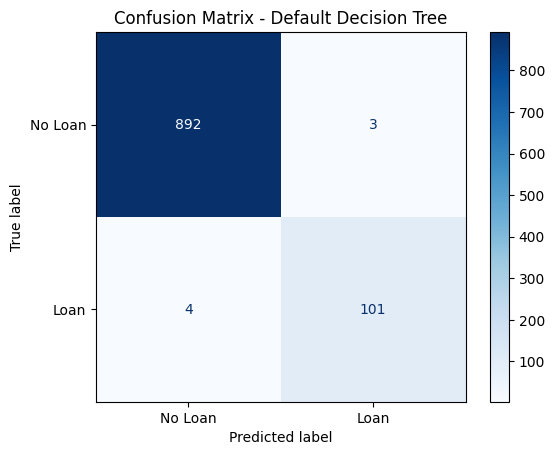

In [71]:
# Initialize and train default decision tree
model_default = DecisionTreeClassifier(random_state=42)
model_default.fit(X_train_processed, y_train)

# Predict on test data
y_pred_default = model_default.predict(X_test_processed)
y_prob_default = model_default.predict_proba(X_test_processed)[:, 1]



# Decision tree visualization
plt.figure(figsize=(20,10))
plot_tree(
    model_default,
    feature_names=numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out()),
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization - Default Model")
plt.show()

# Confusion matrix
cm_default = confusion_matrix(y_test, y_pred_default)
disp_default = ConfusionMatrixDisplay(confusion_matrix=cm_default, display_labels=['No Loan', 'Loan'])
disp_default.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Default Decision Tree')
plt.show()

## Model Performance Improvement

# Pre Prune

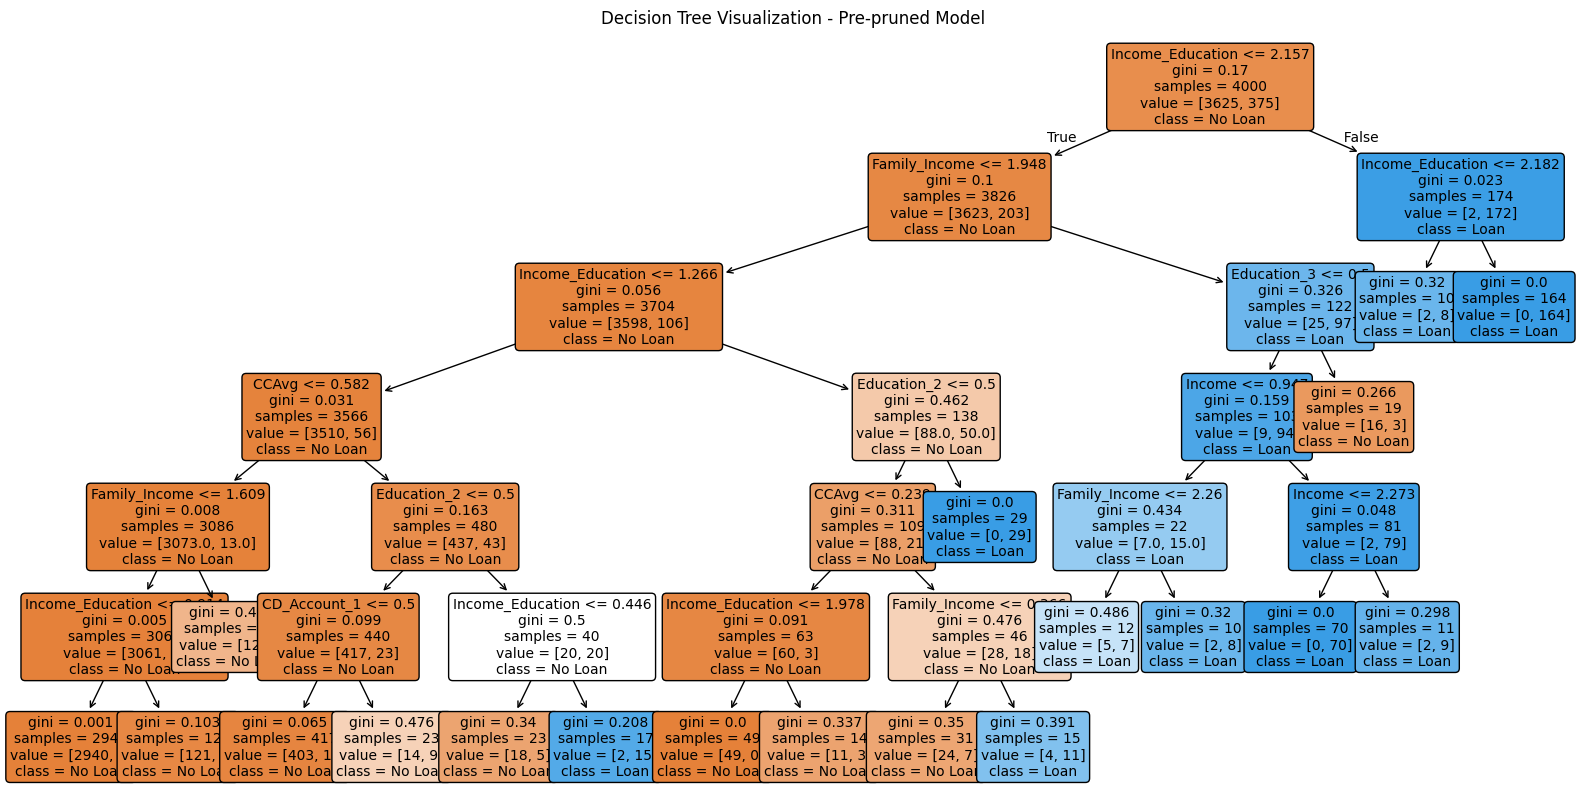

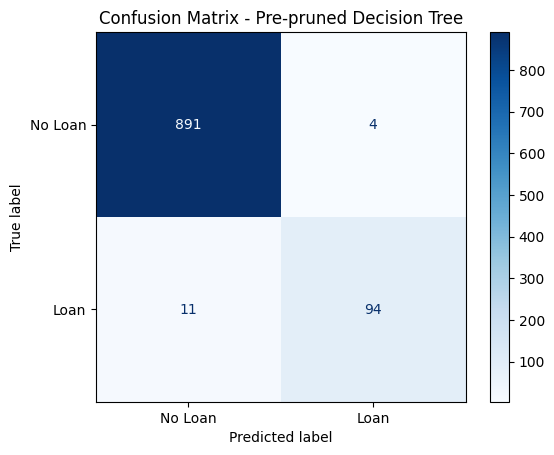

In [75]:
model_prepruned = DecisionTreeClassifier(
    random_state=42,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10
)
model_prepruned.fit(X_train_processed, y_train)

# Predict
y_pred_prepruned = model_prepruned.predict(X_test_processed)
y_prob_prepruned = model_prepruned.predict_proba(X_test_processed)[:, 1]



# Decision tree visualization
plt.figure(figsize=(20,10))
plot_tree(
    model_prepruned,
    feature_names=numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out()),
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization - Pre-pruned Model")
plt.show()

# Confusion matrix
cm_prepruned = confusion_matrix(y_test, y_pred_prepruned)
disp_prepruned = ConfusionMatrixDisplay(confusion_matrix=cm_prepruned, display_labels=['No Loan', 'Loan'])
disp_prepruned.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Pre-pruned Decision Tree')
plt.show()

# Post Prune

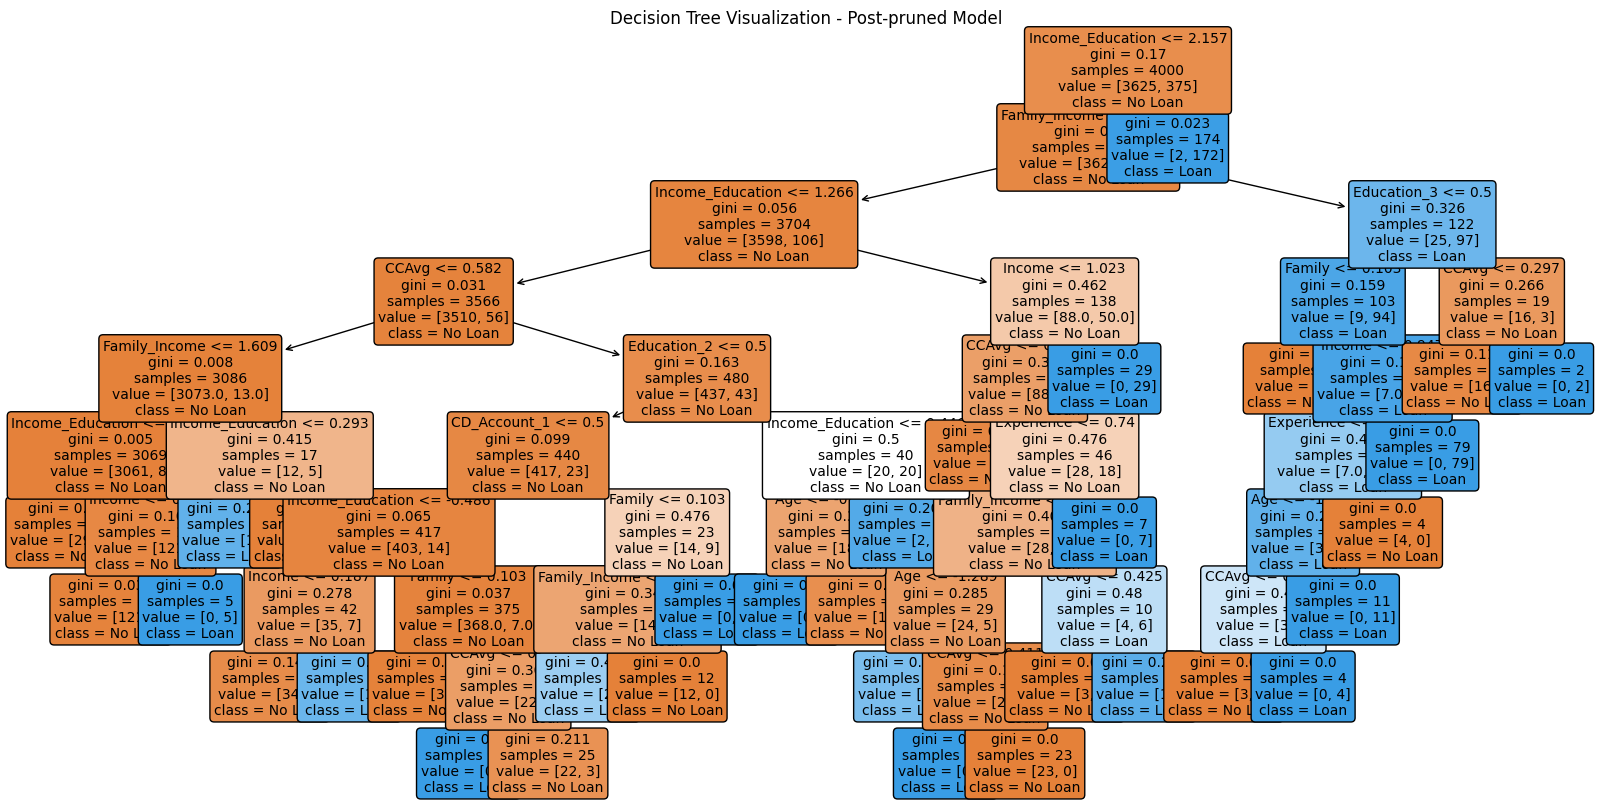

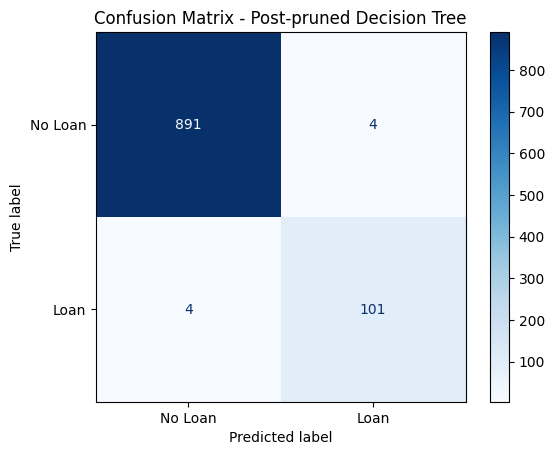

In [73]:
# Get pruning path and alpha
path = model_default.cost_complexity_pruning_path(X_train_processed, y_train)
ccp_alphas = path.ccp_alphas
alpha_to_use = ccp_alphas[len(ccp_alphas)//2]

# Train post-pruned decision tree
model_postpruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_to_use)
model_postpruned.fit(X_train_processed, y_train)

# Predict
y_pred_postpruned = model_postpruned.predict(X_test_processed)
y_prob_postpruned = model_postpruned.predict_proba(X_test_processed)[:, 1]



# Decision tree visualization
plt.figure(figsize=(20,10))
plot_tree(
    model_postpruned,
    feature_names=numeric_features + list(preprocessor.named_transformers_['cat'].get_feature_names_out()),
    class_names=['No Loan', 'Loan'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Visualization - Post-pruned Model")
plt.show()

# Confusion matrix
cm_postpruned = confusion_matrix(y_test, y_pred_postpruned)
disp_postpruned = ConfusionMatrixDisplay(confusion_matrix=cm_postpruned, display_labels=['No Loan', 'Loan'])
disp_postpruned.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Post-pruned Decision Tree')
plt.show()

## Model Performance Comparison and Final Model Selection

In [76]:
metrics_default = {
    'Accuracy': accuracy_score(y_test, y_pred_default),
    'Precision': precision_score(y_test, y_pred_default),
    'Recall': recall_score(y_test, y_pred_default),
    'F1-Score': f1_score(y_test, y_pred_default),
    'ROC-AUC': roc_auc_score(y_test, y_prob_default)
}

metrics_prepruned = {
    'Accuracy': accuracy_score(y_test, y_pred_prepruned),
    'Precision': precision_score(y_test, y_pred_prepruned),
    'Recall': recall_score(y_test, y_pred_prepruned),
    'F1-Score': f1_score(y_test, y_pred_prepruned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_prepruned)
}

metrics_postpruned = {
    'Accuracy': accuracy_score(y_test, y_pred_postpruned),
    'Precision': precision_score(y_test, y_pred_postpruned),
    'Recall': recall_score(y_test, y_pred_postpruned),
    'F1-Score': f1_score(y_test, y_pred_postpruned),
    'ROC-AUC': roc_auc_score(y_test, y_prob_postpruned)
}

# Convert to DataFrame for comparison
df_comparison = pd.DataFrame({
    'Default Decision Tree': pd.Series(metrics_default),
    'Pre-pruned Decision Tree': pd.Series(metrics_prepruned),
    'Post-pruned Decision Tree': pd.Series(metrics_postpruned)
})

print("Model Performance Comparison:")
display(df_comparison)

Model Performance Comparison:


,Default Decision Tree,Pre-pruned Decision Tree,Post-pruned Decision Tree
Accuracy,0.993000,0.985000,0.992000
Precision,0.971154,0.959184,0.961905
Recall,0.961905,0.895238,0.961905
F1-Score,0.966507,0.926108,0.961905
ROC-AUC,0.979276,0.995121,0.988140


**Observation**


1. The default Decision Tree achieves the highest accuracy (99.30%) and recall (96.19%), indicating strong overall correctness and ability to identify true loan buyers.

2. The post-pruned Decision Tree closely follows with high accuracy (99.20%), precision (96.19%), recall (96.19%), and an excellent ROC-AUC (98.81%), showing balanced and robust performance with simpler model complexity.

3. The pre-pruned Decision Tree has the highest ROC-AUC (99.51%), suggesting excellent discriminative ability, but lower recall (89.52%) and F1-Score (92.61%), which means it misses more actual buyers compared to the other models.

**Model Selection**

The default Decision Tree is strong in recall and accuracy but may be more complex and prone to overfitting.

The post-pruned Decision Tree provides a great balance of performance and simplicity, making it suitable for reliable, interpretable predictions and operational use.

The pre-pruned Decision Tree, despite its top ROC-AUC, shows lower recall, so it may not identify as many potential buyers — less ideal if maximizing reach is a priority.



## Actionable Insights and Business Recommendations


1. Leverage the Post-Pruned Decision Tree Model for Targeting
The post-pruned model balances high accuracy, precision, and recall while maintaining model simplicity and interpretability.

  Use it to score liability customers and identify high-probability personal loan buyers for targeted marketing efforts.

2. Maximize Marketing Efficiency
With precision around 96%, the model minimizes false positives, ensuring marketing resources focus on customers most likely to convert, reducing wasted spend.

  Prioritize personalized loan offers and financial education for these segments to improve conversion rates further.

3. Prioritize Key Customer Segments
Focus on customers with higher income, active credit card usage, and existing term deposits (CD accounts) — these attributes strongly correlate with loan uptake.

  Consider segmentation by family size and education level to tailor messaging and product offerings.

4. Use Interaction Features to Refine Targeting
Newly engineered interaction features like Income × Education and Family Size × Income improve predictive accuracy and help identify nuanced customer profiles.

  Deploy these insights to customize campaigns that resonate with different customer segments.

5. Monitor and Iterate
Continuously track campaign outcomes and model performance; retrain the model with fresh data to adapt to changing customer behavior.

  Use feedback loops to refine feature engineering and modeling strategies over time.

___